# PART A: Dataset Analysis

In [1]:
#!rm -rf /kaggle/working/*

## INPUT FILES — Painter by Numbers Dataset

### all_data_info.csv
- Includes artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
- artist_group field says if data is present only in train/test/in both

### replacements_for_corrupted_files.zip
- Contains the replacements for corrupted data
- 3 in test and 7 in train , total 10 to be replaced

### test.zip
- Images in the test set.

### train.zip
- Images in the train set.

### train_1.zip to train_9.zip
- subsets of train.zip.
- Dataset is split into multiple ZIPs to make downloading and processing easier.

### train_info.csv
- Metadata for training images.
- Includes filename,artist,title,style,genre,date.

## Importing All modules

In [2]:
# ===============================
# Standard Library Imports
# ===============================
import itertools
import os
import re
import shutil
import time
import zipfile
from datetime import datetime

# ===============================
# Utility & Progress Tracking
# ===============================
from tqdm import tqdm

# ===============================
# Data Handling & Numerical
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
matplotlib.rc_file_defaults()

# ===============================
# Image Processing
# ===============================
import cv2
from PIL import Image
from skimage.feature import hog

# ===============================
# Scikit-learn
# ===============================
from sklearn import preprocessing, svm
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ===============================
# PyTorch
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import models, transforms

## Loading data

In [3]:
path = '../input/painter-by-numbers/'
df = pd.read_csv(path+'all_data_info.csv')
df.head()

,artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
0,Barnett Newman,1955.0,abstract,15530.0,6911.0,9201912.0,wikiart,Color Field Painting,Uriel,train_only,True,102257.jpg
1,Barnett Newman,1950.0,abstract,14559.0,6866.0,8867532.0,wikiart,Color Field Painting,Vir Heroicus Sublimis,train_only,True,75232.jpg
2,kiri nichol,2013.0,NaN,9003.0,9004.0,1756681.0,NaN,Neoplasticism,NaN,test_only,False,32145.jpg
3,kiri nichol,2013.0,NaN,9003.0,9004.0,1942046.0,NaN,Neoplasticism,NaN,test_only,False,20304.jpg
4,kiri nichol,2013.0,NaN,9003.0,9004.0,1526212.0,NaN,Neoplasticism,NaN,test_only,False,836.jpg


### Dataset details

In [4]:
print(f"The full dataset contains a total of {len(df['artist'].unique())} different artists and {len(df['genre'].unique())} unique painting genres.\n")
print(f"Total images: {len(df)}")

The full dataset contains a total of 2319 different artists and 43 unique painting genres.

Total images: 103250


# Data Cleaning :
## Corrupted Image Replacement

**What this code does:**
1. **Identifies corrupted images** - Reads original images from `train.zip` and `test.zip`
2. **Detects corruption** - Catches images that cannot be loaded (KeyError, UnidentifiedImageError, etc.)
3. **Replaces with fixed versions** - Loads replacement images from `replacements_for_corrupted_files.zip`
4. **Visualizes before/after** - Shows corrupted (black placeholder) vs fixed images side-by-side
5. **Reports statistics** - 10 corrupted images were successfully identified and fixed

In [5]:
archive = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')
train_dir, test_dir = '/kaggle/working/train', '/kaggle/working/test'

corrupted_map = {
    item.split('/')[-1].replace('.jpg', ''): item
    for item in archive.namelist()
    if item.endswith('.jpg')
}

In [6]:
print("="*60)
print("STEP 1: REPLACING CORRUPTED FILES")
print("="*60)

# Create temporary directory for replacements
temp_replacement_dir = '/kaggle/working/temp_replacements'
os.makedirs(temp_replacement_dir, exist_ok=True)

# Open replacement zip (using your corrupted_map)
replacement_zip = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')

# Filter out Mac OS hidden files (._*) and count unique corrupted files
unique_corrupted = set([img_id for img_id in corrupted_map.keys() if not img_id.startswith('._')])
print(f"\n🔧 Found {len(unique_corrupted)} unique corrupted files (filtered out Mac OS metadata)")
print(f"📋 Corrupted file IDs: {sorted(list(unique_corrupted))}\n")

print(f"Extracting replacement files...")
for img_id, zip_path in tqdm(corrupted_map.items(), desc="Replacing corrupted files"):
    # Skip Mac OS metadata files
    if img_id.startswith('._'):
        continue
    
    filename = img_id + '.jpg'
    output_path = os.path.join(temp_replacement_dir, filename)
    try:
        img_bytes = replacement_zip.read(zip_path)
        with open(output_path, 'wb') as f:
            f.write(img_bytes)
    except Exception as e:
        print(f"❌ Failed to extract replacement {img_id}: {e}")

replacement_zip.close()
print(f"✅ All corrupted files replaced!\n")

print("="*60)
print("STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)")
print("="*60)

# Find top 24 artists by image count
print("\n🎨 Finding top 24 artists...")
artist_counts = df['artist'].value_counts()
top_24_artists = artist_counts.head(24).index.tolist()

print(f"✅ Top 24 artists (original counts):")
for i, (artist, count) in enumerate(artist_counts.head(24).items(), 1):
    print(f"   {i:2d}. {artist}: {count} images")

# Sample 495 images per artist uniformly
print(f"\n📊 Sampling 495 images per artist for uniformity...")
df_top24_balanced = []
for artist in top_24_artists:
    artist_df = df[df['artist'] == artist]
    if len(artist_df) >= 495:
        sampled = artist_df.sample(n=495, random_state=42)
    else:
        print(f"⚠️ {artist} has only {len(artist_df)} images (< 495)")
        sampled = artist_df
    df_top24_balanced.append(sampled)

df_top24 = pd.concat(df_top24_balanced, ignore_index=True)
print(f"\n✅ Balanced dataset: {len(df_top24)} total images (495 per artist × 24 artists)\n")

# Setup output directories
output_train = '/kaggle/working/train_top24'
output_test = '/kaggle/working/test_top24'
os.makedirs(output_train, exist_ok=True)
os.makedirs(output_test, exist_ok=True)

# Open zip files
train_zip = zipfile.ZipFile(path + 'train.zip', 'r')
test_zip = zipfile.ZipFile(path + 'test.zip', 'r')

# Build zip file indices
print("🔍 Building zip file indices...")
train_zip_lookup = {}
for name in train_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        train_zip_lookup[filename] = name

test_zip_lookup = {}
for name in test_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        test_zip_lookup[filename] = name

print(f"📊 Found {len(train_zip_lookup)} train images in zip")
print(f"📊 Found {len(test_zip_lookup)} test images in zip\n")

replaced_count = 0
extracted_count = 0
not_found = []

# Process balanced top 24 artists' images
for _, row in tqdm(df_top24.iterrows(), total=len(df_top24), desc="Extracting balanced dataset"):
    filename = row['new_filename']
    img_id = filename.replace('.jpg', '')
    
    # Determine output directory based on where file exists
    if filename in train_zip_lookup:
        output_dir = output_train
        source_zip = train_zip
        zip_lookup = train_zip_lookup
    elif filename in test_zip_lookup:
        output_dir = output_test
        source_zip = test_zip
        zip_lookup = test_zip_lookup
    else:
        not_found.append(filename)
        continue
    
    output_path = os.path.join(output_dir, filename)
    
    # Check if this image was replaced (use replacement file)
    replacement_path = os.path.join(temp_replacement_dir, filename)
    if os.path.exists(replacement_path):
        # Use REPLACEMENT image from temp directory
        try:
            with open(replacement_path, 'rb') as f_in:
                with open(output_path, 'wb') as f_out:
                    f_out.write(f_in.read())
            replaced_count += 1
        except Exception as e:
            print(f"❌ Failed to copy replacement {filename}: {e}")
            not_found.append(filename)
    else:
        # Use ORIGINAL image from zip
        try:
            img_bytes = source_zip.read(zip_lookup[filename])
            with open(output_path, 'wb') as f:
                f.write(img_bytes)
            extracted_count += 1
        except Exception as e:
            print(f"❌ Failed to extract {filename}: {e}")
            not_found.append(filename)

# Close zip files
train_zip.close()
test_zip.close()

print(f"\n{'='*60}")
print(f"FINAL STATISTICS")
print(f"{'='*60}")
print(f" Total images extracted: {extracted_count + replaced_count}")
print(f" Corrupted images replaced: {replaced_count}")
print(f" Original images extracted: {extracted_count}")
print(f" Images not found: {len(not_found)}")
print(f"{'='*60}")

if not_found and len(not_found) < 20:
    print(f"\n❌ Missing files: {not_found}")

print(f"\n Balanced top 24 artists dataset ready at:")
print(f"   Training images: {output_train}/")
print(f"   Test images: {output_test}/")

# Save filtered dataframe for future use
df_top24.to_csv('/kaggle/working/top24_artists_balanced_info.csv', index=False)
print(f"\n💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv")
print(f"\n💡 Use this balanced dataset for fair model training!")

# Clean up temp directory
shutil.rmtree(temp_replacement_dir)
print(f"🧹 Cleaned up temporary files")

STEP 1: REPLACING CORRUPTED FILES

🔧 Found 10 unique corrupted files (filtered out Mac OS metadata)
📋 Corrupted file IDs: ['100532', '101947', '18649', '20153', '3917', '41945', '79499', '91033', '92899', '95347']

Extracting replacement files...


Replacing corrupted files: 100%|██████████| 20/20 [00:00<00:00, 97.21it/s]


✅ All corrupted files replaced!

STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)

🎨 Finding top 24 artists...
✅ Top 24 artists (original counts):
    1. Giovanni Battista Piranesi: 500 images
    2. Rembrandt: 500 images
    3. Ivan Shishkin: 500 images
    4. Gustave Dore: 500 images
    5. Pablo Picasso: 500 images
    6. Pierre-Auguste Renoir: 500 images
    7. Zdislav Beksinski: 500 images
    8. Ilya Repin: 500 images
    9. Marc Chagall: 500 images
   10. Ivan Aivazovsky: 500 images
   11. Albrecht Durer: 500 images
   12. John Singer Sargent: 500 images
   13. Martiros Saryan: 499 images
   14. Paul Cezanne: 499 images
   15. Camille Pissarro: 499 images
   16. Pyotr Konchalovsky: 499 images
   17. Boris Kustodiev: 498 images
   18. Paul Gauguin: 498 images
   19. Claude Monet: 498 images
   20. Raphael Kirchner: 497 images
   21. Eugene Boudin: 496 images
   22. Nicholas Roerich: 496 images
   23. Henri Matisse: 495 images
   24. Edgar Degas: 495 images

📊 Sampling 495

Extracting balanced dataset: 100%|██████████| 11880/11880 [02:03<00:00, 95.96it/s] 



FINAL STATISTICS
 Total images extracted: 11880
 Corrupted images replaced: 0
 Original images extracted: 11880
 Images not found: 0

 Balanced top 24 artists dataset ready at:
   Training images: /kaggle/working/train_top24/
   Test images: /kaggle/working/test_top24/

💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv

💡 Use this balanced dataset for fair model training!
🧹 Cleaned up temporary files


In [7]:
# Select Top 24 Artists

df_top24 = pd.read_csv('/kaggle/working/top24_artists_balanced_info.csv')

N = 24  # Number of artists
paintings = df_top24['artist'].value_counts()
artists = paintings.index.tolist()
sample_size = 495  # Already balanced to 495 per artist

print(f"Selected {N} artists for classification:")
for i, artist in enumerate(artists, 1):
    print(f"{i}. {artist}: {paintings[artist]} paintings")
print(f"\nSample size per artist (balanced dataset): {sample_size} paintings")
print(f"Total images to be used: {N * sample_size} = {len(df_top24)}")


Selected 24 artists for classification:
1. Giovanni Battista Piranesi: 495 paintings
2. Rembrandt: 495 paintings
3. Ivan Shishkin: 495 paintings
4. Gustave Dore: 495 paintings
5. Pablo Picasso: 495 paintings
6. Pierre-Auguste Renoir: 495 paintings
7. Zdislav Beksinski: 495 paintings
8. Ilya Repin: 495 paintings
9. Marc Chagall: 495 paintings
10. Ivan Aivazovsky: 495 paintings
11. Albrecht Durer: 495 paintings
12. John Singer Sargent: 495 paintings
13. Martiros Saryan: 495 paintings
14. Paul Cezanne: 495 paintings
15. Camille Pissarro: 495 paintings
16. Pyotr Konchalovsky: 495 paintings
17. Boris Kustodiev: 495 paintings
18. Paul Gauguin: 495 paintings
19. Claude Monet: 495 paintings
20. Raphael Kirchner: 495 paintings
21. Eugene Boudin: 495 paintings
22. Nicholas Roerich: 495 paintings
23. Henri Matisse: 495 paintings
24. Edgar Degas: 495 paintings

Sample size per artist (balanced dataset): 495 paintings
Total images to be used: 11880 = 11880


In [8]:
# Create a copy
active_df = df_top24.copy()

print(f"Total images selected: {len(active_df)}")
print(f"Images per artist: {sample_size}")
print(f"Number of artists: {len(artists)}")

# Verify balance
print("\nClass distribution:")
print(active_df['artist'].value_counts())


Total images selected: 11880
Images per artist: 495
Number of artists: 24

Class distribution:
artist
Giovanni Battista Piranesi    495
Rembrandt                     495
Ivan Shishkin                 495
Gustave Dore                  495
Pablo Picasso                 495
Pierre-Auguste Renoir         495
Zdislav Beksinski             495
Ilya Repin                    495
Marc Chagall                  495
Ivan Aivazovsky               495
Albrecht Durer                495
John Singer Sargent           495
Martiros Saryan               495
Paul Cezanne                  495
Camille Pissarro              495
Pyotr Konchalovsky            495
Boris Kustodiev               495
Paul Gauguin                  495
Claude Monet                  495
Raphael Kirchner              495
Eugene Boudin                 495
Nicholas Roerich              495
Henri Matisse                 495
Edgar Degas                   495
Name: count, dtype: int64


In [9]:
# Label Encoder Setup

LabEnc = preprocessing.LabelEncoder()
LabEnc.fit(artists)

print(f"Number of classes: {len(artists)}")
print(f"\nArtist Label Mapping:")
for i, artist in enumerate(artists):
    print(f"{i}: {artist}")

Number of classes: 24

Artist Label Mapping:
0: Giovanni Battista Piranesi
1: Rembrandt
2: Ivan Shishkin
3: Gustave Dore
4: Pablo Picasso
5: Pierre-Auguste Renoir
6: Zdislav Beksinski
7: Ilya Repin
8: Marc Chagall
9: Ivan Aivazovsky
10: Albrecht Durer
11: John Singer Sargent
12: Martiros Saryan
13: Paul Cezanne
14: Camille Pissarro
15: Pyotr Konchalovsky
16: Boris Kustodiev
17: Paul Gauguin
18: Claude Monet
19: Raphael Kirchner
20: Eugene Boudin
21: Nicholas Roerich
22: Henri Matisse
23: Edgar Degas


## Few Function def for :
-  ### Image Preprocessing
-  ### Dataset Construction
-  ### Evaluation & Visualization

Original image:
Cropped transformed image:
Resized with padding:
Resized with normalization:


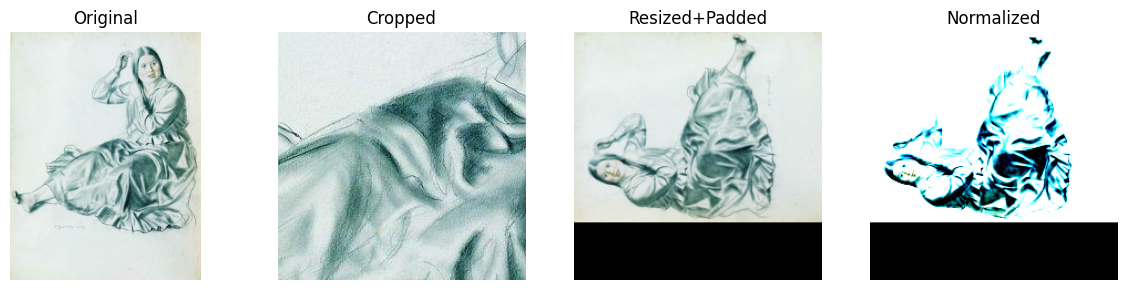

In [10]:
# Image Transformer Function

def image_transformer_nn(image, apply_norm=True, crop_img=True, new_dim=224):
    """
    Args:
        image: PIL Image object
        apply_norm (bool): Apply ImageNet normalization
        crop_img (bool): Crop center square vs resize with padding
        new_dim (int): Target dimension (224 for ResNet)
    """
    if crop_img:
        cropper = transforms.CenterCrop(new_dim)
        image = cropper(image)
    
    tensoring = transforms.ToTensor()
    image = tensoring(image)
    channels, height, width = image.shape
    
    # Handle grayscale images
    if image.shape[0] < 3:
        image = image.expand(3, -1, -1)
    # Handle extra channels
    if image.shape[0] > 3:
        image = image[0:3, :, :]
    
    # ImageNet normalization
    if apply_norm:
        normalizer = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        image = normalizer(image)
    
    if not crop_img:
        if width < height:
            image = image.transpose(1, 2)
        channels, height, width = image.shape
        res_percent = float(new_dim / width)
        height = round(height * res_percent)
        resizer = transforms.Resize((height, new_dim))
        image = resizer(image)
        padder = transforms.Pad([0, 0, 0, int(new_dim - height)])
        image = padder(image)
    
    return image

# Example usage with extracted files
train_images_path = '/kaggle/working/train_top24/'
test_images_path = '/kaggle/working/test_top24/'

# Get a sample image file
sample_files = [f for f in os.listdir(train_images_path) if f.endswith('.jpg')]
if sample_files:
    sample_file = sample_files[0]
    image = Image.open(os.path.join(train_images_path, sample_file))
    
    print("Original image:")
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')
    
    print("Cropped transformed image:")
    image2 = image_transformer_nn(image, apply_norm=False, crop_img=True, new_dim=224)
    plt.subplot(1, 4, 2)
    plt.imshow(image2.numpy().transpose(1, 2, 0))
    plt.title("Cropped")
    plt.axis('off')
    
    print("Resized with padding:")
    image3a = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 3)
    plt.imshow(image3a.numpy().transpose(1, 2, 0))
    plt.title("Resized+Padded")
    plt.axis('off')
    
    print("Resized with normalization:")
    image3b = image_transformer_nn(image, apply_norm=True, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 4)
    plt.imshow(image3b.numpy().transpose(1, 2, 0))
    plt.title("Normalized")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [11]:
# ImageDataset Class for Neural Networks

class ImageDataset(Dataset):
    def __init__(self, dataframe, lab_encoder, img_size=224, normalize=True, crop=False):
        """
        Args:
            dataframe (pd.DataFrame): Dataframe with image info
            lab_encoder: Label encoder for artist names
            img_size (int): Image dimension (default 224)
            normalize (bool): Apply ImageNet normalization
            crop (bool): True=crop center, False=resize with padding
        """
        self.encoder = lab_encoder
        self.img_size = img_size
        self.normalize = normalize
        self.crop = crop
        self.train_path = '/kaggle/working/train_top24/'
        self.test_path = '/kaggle/working/test_top24/'
        self.feats, self.labels = self.get_all_items(dataframe)
    
    def get_all_items(self, dataframe):
        feats = []
        labels = []
        
        for index, row in dataframe.iterrows():
            filename = row['new_filename']
            
            # Determine if image is in train or test
            if row['in_train']:
                img_path = os.path.join(self.train_path, filename)
            else:
                img_path = os.path.join(self.test_path, filename)
            
            try:
                # Load image from extracted files
                image = Image.open(img_path)
                datum = image_transformer_nn(image, apply_norm=self.normalize,
                                            crop_img=self.crop, new_dim=self.img_size)
                feats.append(datum)
                
                # Label
                artist = row['artist']
                label = self.encoder.transform([artist])[0]
                labels.append(label)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        
        feats = torch.stack(feats)
        labels = torch.LongTensor(labels)
        return feats, labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, item):
        return self.feats[item], self.labels[item]

In [12]:
# ImageData Function for SVM/Other Models

def ImageData(dataframe, lab_encoder, hog_mode=None, sift_mode=None, img_size=224):
    """
    Load images for non-NN models (SVM, etc.)
    
    Args:
        dataframe: Dataframe with image info
        lab_encoder: Label encoder
        hog_mode: Tuple (orientations, pixels_per_cell, cells_per_block) or None
        sift_mode: True to use SIFT features, False otherwise
        img_size: Image dimension
    """
    train_path = '/kaggle/working/train_top24/'
    test_path = '/kaggle/working/test_top24/'
    
    PaintFeats = []
    PaintLabels = []
    
    for index, row in dataframe.iterrows():
        filename = row['new_filename']
        
        # Determine path
        if row['in_train']:
            img_path = os.path.join(train_path, filename)
        else:
            img_path = os.path.join(test_path, filename)
        
        try:
            image = Image.open(img_path)
            datum = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=img_size)
            np_datum = datum.numpy().transpose(1, 2, 0)
            
            if hog_mode:
                orients, ppc, cpb = hog_mode[0], hog_mode[1], hog_mode[2]
                datum = hog(np_datum, orientations=orients, pixels_per_cell=ppc,
                           cells_per_block=cpb, feature_vector=True, channel_axis=2)
                PaintFeats.append(datum)
            
            elif sift_mode:
                np_datum = cv2.normalize(np_datum, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
                imgtogray = cv2.cvtColor(np_datum, cv2.COLOR_BGR2GRAY)
                PaintFeats.append(imgtogray)
            
            # Label
            artist = row['artist']
            label = lab_encoder.transform([artist])[0]
            PaintLabels.append(label)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    return np.asarray(PaintFeats), np.asarray(PaintLabels)


In [13]:

# Data Splitter Function

def DataSplitter(data, ratios=[60, 20, 20], need_val=True, batches=None, shuffle=True, seed=42):
    """
    Split data into train/val/test sets
    
    Args:
        data: ImageDataset or tuple (X, y)
        ratios: [train%, val%, test%]
        need_val: Whether to create validation set
        batches: Batch size for DataLoaders (NN case)
        shuffle: Shuffle data
        seed: Random seed
    """
    first_ratio = (ratios[1] + ratios[2]) / sum(ratios)
    second_ratio = ratios[2] / (ratios[1] + ratios[2])
    
    if isinstance(data, ImageDataset):  # Neural Network case
        labels = data.labels.numpy()
        
        train_indices, rest_indices = train_test_split(
            np.arange(len(labels)),
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=labels
        )
        
        rest_labels = data[rest_indices][1]
        
        val_indices, test_indices = train_test_split(
            rest_indices,
            test_size=second_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=rest_labels
        )
        
        train_sampler = SubsetRandomSampler(train_indices)
        val_sampler = SubsetRandomSampler(val_indices)
        test_sampler = SubsetRandomSampler(test_indices)
        
        train_loader = DataLoader(data, batch_size=batches, sampler=train_sampler)
        val_loader = DataLoader(data, batch_size=batches, sampler=val_sampler)
        test_loader = DataLoader(data, batch_size=batches, sampler=test_sampler)
        
        return train_loader, val_loader, test_loader
    
    elif isinstance(data, tuple):  # SVM/other models case
        X_train, X_rest, y_train, y_rest = train_test_split(
            data[0], data[1],
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=data[1]
        )
        
        if need_val:
            X_val, X_test, y_val, y_test = train_test_split(
                X_rest, y_rest,
                test_size=second_ratio,
                shuffle=shuffle,
                random_state=seed,
                stratify=y_rest
            )
            return X_train, X_val, X_test, y_train, y_val, y_test
        
        return X_train, X_rest, y_train, y_rest
    
    else:
        print('Invalid data type. Use ImageDataset or tuple (X, y).')
        return

In [14]:
# Visualization Functions

sns.set(style="darkgrid")

def CustomCmap(from_rgb, to_rgb):
    """Create custom colormap"""
    r1, g1, b1 = from_rgb
    r2, g2, b2 = to_rgb
    cdict = {
        'red': ((0, r1, r1), (1, r2, r2)),
        'green': ((0, g1, g1), (1, g2, g2)),
        'blue': ((0, b1, b1), (1, b2, b2))
    }
    cmap = LinearSegmentedColormap('custom_cmap', cdict)
    return cmap

mycmap = CustomCmap([1.0, 1.0, 1.0], [72/255, 99/255, 147/255])
mycmap_r = CustomCmap([72/255, 99/255, 147/255], [1.0, 1.0, 1.0])
mycol = (72/255, 99/255, 147/255)
mycomplcol = (129/255, 143/255, 163/255)

def plot_cm(cfmatrix, title, classes):
    """Plot confusion matrix"""
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 10))
    
    im = ax1.imshow(cfmatrix, interpolation='nearest', cmap=mycmap)
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    plt.colorbar(im, cax=cax)
    
    ax1.set_title(title, fontsize=14)
    tick_marks = np.arange(len(classes))
    ax1.set_xticks(tick_marks)
    ax1.set_xticklabels(classes, rotation=90)
    ax1.set_yticks(tick_marks)
    ax1.set_yticklabels(classes)
    
    fmt = 'd'
    thresh = cfmatrix.max() / 2.
    for i, j in itertools.product(range(cfmatrix.shape[0]), range(cfmatrix.shape[1])):
        ax1.text(j, i, format(cfmatrix[i, j], fmt),
                horizontalalignment="center",
                color="white" if cfmatrix[i, j] > thresh else "black")
    
    ax1.set_ylabel('True label', fontsize=14)
    ax1.set_xlabel('Predicted label', fontsize=14)
    plt.savefig(title + '.pdf', bbox_inches='tight')
    plt.show()

print("All blocks loaded successfully!")
print(f"Ready to proceed to Part B with {N} artists and {len(active_df)} images!")

All blocks loaded successfully!
Ready to proceed to Part B with 24 artists and 11880 images!


# PART B: CNN Model

In [15]:
%%time
# Load the Dataset for NN training
nn_data = ImageDataset(active_df, LabEnc, img_size=224, normalize=True, crop=False)
print(f"✅ Dataset loaded with {len(nn_data)} images")
print(f"   Image shape: {nn_data[0][0].shape}")
print(f"   Number of classes: {len(artists)}")

Error loading 81823.jpg: Image size (669000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
✅ Dataset loaded with 11879 images
   Image shape: torch.Size([3, 224, 224])
   Number of classes: 24
CPU times: user 13min 31s, sys: 4min 20s, total: 17min 51s
Wall time: 9min 45s


In [16]:
# Create Data Loaders with Optimal Batch Size
# Larger batch size for better GPU utilization and stable gradients
BATCH_SIZE = 64  

train_loader, val_loader, test_loader = DataSplitter(
    nn_data, 
    ratios=[60, 25, 15], 
    need_val=True, 
    batches=BATCH_SIZE, 
    shuffle=True, 
    seed=42  # Changed to 42 for consistency
)

# Verify splits
print(f"\n📊 Data Split Information:")
print(f"   Training batches: {len(train_loader)} (samples: {len(train_loader)*BATCH_SIZE})")
print(f"   Validation batches: {len(val_loader)} (samples: {len(val_loader)*BATCH_SIZE})")
print(f"   Test batches: {len(test_loader)} (samples: {len(test_loader)*BATCH_SIZE})")



📊 Data Split Information:
   Training batches: 112 (samples: 7168)
   Validation batches: 47 (samples: 3008)
   Test batches: 28 (samples: 1792)


### CNN 

In [17]:
# IMPROVED Base CNN Architecture

class ImprovedCNNBackbone(nn.Module):
    """
    Enhanced CNN with modern techniques:
    - Batch Normalization after each conv layer
    - Dropout for regularization
    - Progressive channel increase
    - Global Average Pooling
    - Label Smoothing support
    """
    def __init__(self, num_classes, dropout=0.5):
        super(ImprovedCNNBackbone, self).__init__()
        
        # Convolutional layers with BatchNorm
        self.features = nn.Sequential(
            # Block 1: 224x224 -> 112x112
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: 112x112 -> 56x56
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: 56x56 -> 28x28
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4: 28x28 -> 14x14
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Global Average Pooling (better than flatten)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ============================================================================
# IMPROVED Training Functions with Modern Techniques
# ============================================================================

class LabelSmoothingCrossEntropy(nn.Module):
    """Label smoothing to prevent overconfidence"""
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        n_class = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_class
        log_prob = F.log_softmax(pred, dim=1)
        loss = -(one_hot * log_prob).sum(dim=1).mean()
        return loss


def training_loop_improved(model, train_dataloader, optimizer, loss_fn, device="cuda"):
    """Improved training loop with accuracy tracking"""
    model.train()
    batch_losses = []
    correct = 0
    total = 0
    
    for batch in train_dataloader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        yhat = model(x_batch)
        loss = loss_fn(yhat, y_batch)
        
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        batch_losses.append(loss.item())
        
        # Calculate accuracy
        _, predicted = torch.max(yhat.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    train_loss = np.mean(batch_losses)
    train_acc = 100 * correct / total
    
    return train_loss, train_acc


def validation_loop_improved(model, val_dataloader, loss_fn, device="cuda"):
    """Improved validation loop with accuracy tracking"""
    model.eval()
    batch_losses = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in val_dataloader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            yhat = model(x_batch)
            loss = loss_fn(yhat, y_batch)
            
            batch_losses.append(loss.item())
            
            # Calculate accuracy
            _, predicted = torch.max(yhat.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    val_loss = np.mean(batch_losses)
    val_acc = 100 * correct / total
    
    return val_loss, val_acc


class EarlyStoppingImproved:
    """Enhanced early stopping with model checkpoint"""
    def __init__(self, patience=10, verbose=True, delta=0.001, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
    
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'   ⚠️ EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'   ✅ Val loss decreased ({self.val_loss_min:.4f} → {val_loss:.4f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


def train_improved(model, train_loader, val_loader, optimizer, scheduler, epochs, 
                   loss_fn, device="cuda", patience=10, verbose_ct=1):
    """
    Improved training function with:
    - Learning rate scheduling
    - Early stopping
    - Accuracy tracking
    - Better progress reporting
    """
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    print(f"🚀 Starting Improved CNN Training")
    print(f"   Device: {device}")
    print(f"   Epochs: {epochs}")
    print(f"   Batch Size: {train_loader.batch_size if hasattr(train_loader, 'batch_size') else 'N/A'}")
    print(f"   Patience: {patience}")
    print("=" * 70)
    
    checkpoint_path = 'checkpoint_base_cnn.pt'
    model_path = 'ImprovedCNN.pt'
    
    early_stopping = EarlyStoppingImproved(patience=patience, verbose=True, path=checkpoint_path)
    
    best_val_acc = 0
    
    for epoch in range(epochs):
        # Training
        train_loss, train_acc = training_loop_improved(model, train_loader, optimizer, loss_fn, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation
        val_loss, val_acc = validation_loop_improved(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Learning rate scheduling
        if scheduler is not None:
            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]['lr']
        
        # Early stopping check
        early_stopping(val_loss, model)
        
        # Track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        # Progress reporting
        if epoch % verbose_ct == 0 or epoch == epochs - 1:
            print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            if scheduler is not None:
                print(f"   Learning Rate: {current_lr:.6f}")
        
        if early_stopping.early_stop:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            print(f"   Loading best model from checkpoint...")
            model.load_state_dict(torch.load(checkpoint_path))
            break
    
    # Save final model
    torch.save(model.state_dict(), model_path)
    print(f"\n✅ Training completed!")
    print(f"   Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"   Model saved to: {model_path}")
    
    return train_losses, val_losses, train_accs, val_accs


def evaluate_improved(model, test_loader, device="cuda"):
    """Improved evaluation with detailed metrics"""
    model.eval()
    predictions = []
    labels = []
    
    print("🔍 Evaluating model on test set...")
    
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            yhat = model(x_batch)
            yhat_idx = torch.argmax(yhat, dim=1)
            
            predictions.append(yhat_idx.cpu().numpy())
            labels.append(y_batch.cpu().numpy())
    
    y_pred = np.concatenate(predictions, axis=0)
    y_true = np.concatenate(labels, axis=0)
    
    # Calculate accuracy
    accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
    print(f"✅ Test Accuracy: {accuracy:.2f}%")
    
    return y_pred, y_true


def plot_training_metrics(train_losses, val_losses, train_accs, val_accs, title_prefix="ImprovedCNN"):
    """Plot both loss and accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(train_losses, label="Training Loss", color=mycol, linewidth=2)
    ax1.plot(val_losses, label="Validation Loss", color=mycomplcol, linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(train_accs, label="Training Accuracy", color=mycol, linewidth=2)
    ax2.plot(val_accs, label="Validation Accuracy", color=mycomplcol, linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{title_prefix}_Training_Metrics.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"📊 Training metrics plot saved as '{title_prefix}_Training_Metrics.pdf'")



In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


TRAINING IMPROVED BASE CNN

📋 Model Architecture:
   Total parameters: 4,826,712
   Trainable parameters: 4,826,712
🚀 Starting Improved CNN Training
   Device: cuda
   Epochs: 50
   Batch Size: 64
   Patience: 15


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   ✅ Val loss decreased (inf → 2.8666). Saving model...
Epoch [  1/50] | Train Loss: 2.9232 | Train Acc: 14.59% | Val Loss: 2.8666 | Val Acc: 18.18%
   Learning Rate: 0.001000
   ✅ Val loss decreased (2.8666 → 2.6409). Saving model...
Epoch [  2/50] | Train Loss: 2.7442 | Train Acc: 19.87% | Val Loss: 2.6409 | Val Acc: 24.21%
   Learning Rate: 0.001000
   ⚠️ EarlyStopping counter: 1/15
Epoch [  3/50] | Train Loss: 2.6115 | Train Acc: 25.59% | Val Loss: 2.7058 | Val Acc: 23.30%
   Learning Rate: 0.001000
   ✅ Val loss decreased (2.6409 → 2.4447). Saving model...
Epoch [  4/50] | Train Loss: 2.5303 | Train Acc: 28.39% | Val Loss: 2.4447 | Val Acc: 31.38%
   Learning Rate: 0.001000
   ✅ Val loss decreased (2.4447 → 2.4148). Saving model...
Epoch [  5/50] | Train Loss: 2.4646 | Train Acc: 31.32% | Val Loss: 2.4148 | Val Acc: 32.86%
   Learning Rate: 0.001000
   ✅ Val loss decreased (2.4148 → 2.3289). Saving model...
Epoch [  6/50] | Train Loss: 2.3969 | Train Acc: 33.13% | Val Loss: 2.3289

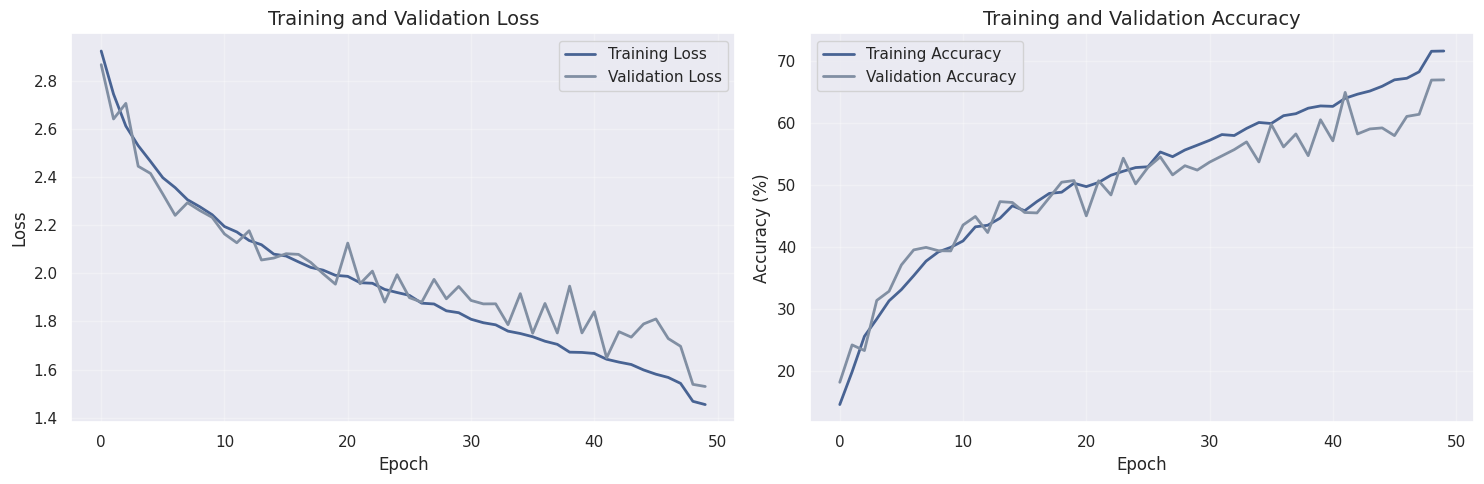

📊 Training metrics plot saved as 'ImprovedCNN_Training_Metrics.pdf'
🔍 Evaluating model on test set...
✅ Test Accuracy: 66.67%

📊 Classification Report:
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.70      0.58      0.64        74
                 Rembrandt       0.50      0.61      0.55        74
             Ivan Shishkin       0.67      0.50      0.57        74
              Gustave Dore       0.61      0.82      0.70        74
             Pablo Picasso       0.45      0.58      0.51        74
     Pierre-Auguste Renoir       0.71      0.88      0.78        74
         Zdislav Beksinski       0.96      0.99      0.97        75
                Ilya Repin       0.99      0.92      0.95        75
              Marc Chagall       0.50      0.64      0.56        74
           Ivan Aivazovsky       0.56      0.55      0.56        74
            Albrecht Durer       0.72      0.91      0.80        75
       John Singer Sargent     

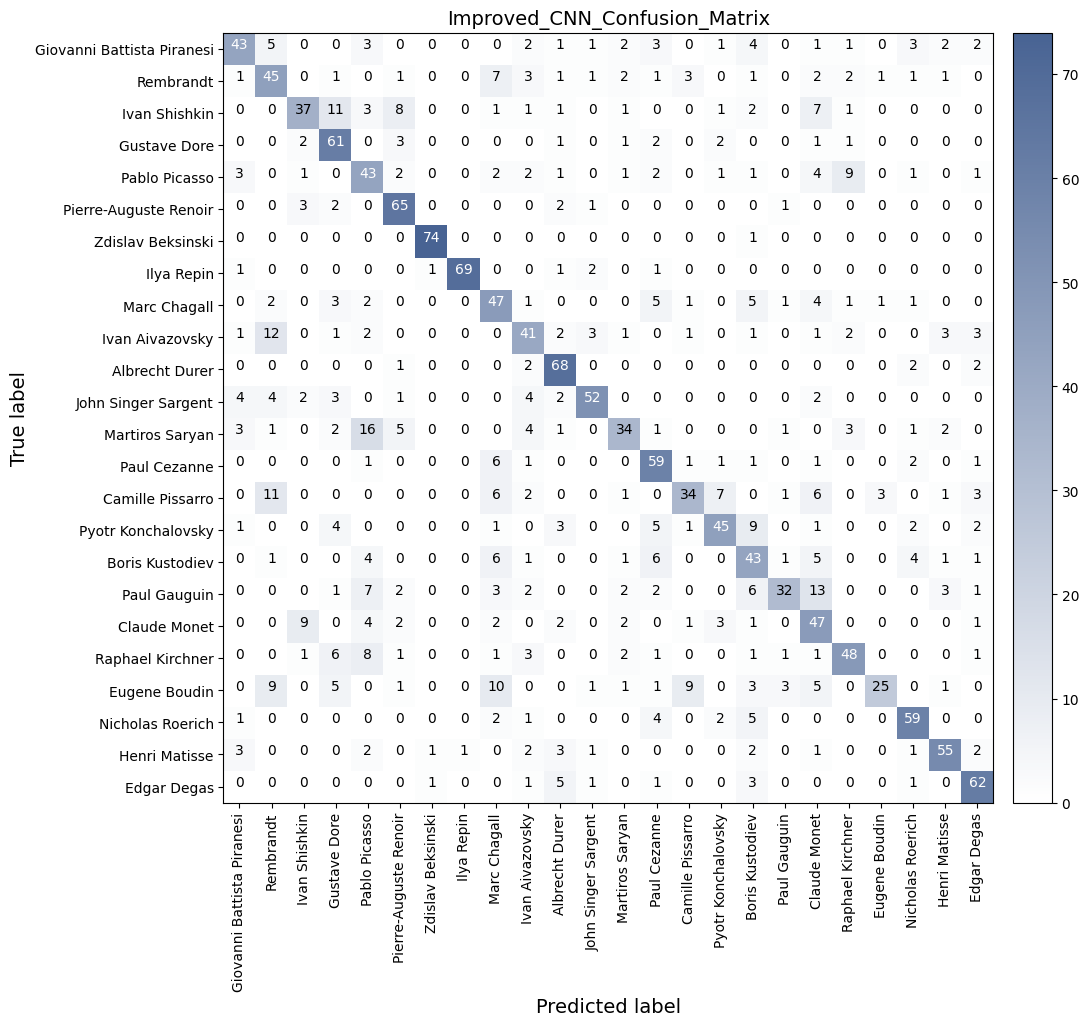

CPU times: user 45min 41s, sys: 2.42 s, total: 45min 44s
Wall time: 43min 20s


In [19]:
%%time

print("\n" + "="*70)
print("TRAINING IMPROVED BASE CNN")
print("="*70)

# Hyperparameters (optimized for better performance)
learning_rate = 0.001  # Higher initial LR with scheduler
weight_decay = 1e-4    # Regularization
dropout = 0.5
patience = 15
epochs = 50
verbose_ct = 1

# Initialize improved model
model_cnn_improved = ImprovedCNNBackbone(num_classes=len(artists), dropout=dropout)
model_cnn_improved = model_cnn_improved.to(device)

print(f"\n📋 Model Architecture:")
print(f"   Total parameters: {sum(p.numel() for p in model_cnn_improved.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model_cnn_improved.parameters() if p.requires_grad):,}")

# Loss function with label smoothing
loss_function = LabelSmoothingCrossEntropy(smoothing=0.1)

# Optimizer
optimizer = torch.optim.AdamW(model_cnn_improved.parameters(), 
                              lr=learning_rate, 
                              weight_decay=weight_decay)

# Learning rate scheduler (reduces LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)

# Train the model
t_losses, v_losses, t_accs, v_accs = train_improved(
    model_cnn_improved, train_loader, val_loader, 
    optimizer, scheduler, epochs,
    loss_function, device=device, 
    patience=patience, verbose_ct=verbose_ct
)

# Plot training metrics
plot_training_metrics(t_losses, v_losses, t_accs, v_accs, 
                     title_prefix='ImprovedCNN')

# Evaluate on test set
predictions, labels = evaluate_improved(model_cnn_improved, test_loader, device=device)

# Classification report
print("\n📊 Classification Report:")
print(classification_report(labels, predictions, target_names=artists))

# Confusion matrix
matplotlib.rc_file_defaults()
cfmatrix = confusion_matrix(labels, predictions)
plot_cm(cfmatrix, 'Improved_CNN_Confusion_Matrix', artists)



### TRANSFER LEARNING : RESNET-18


TRAINING RESNET-18 (TRANSFER LEARNING)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


📋 ResNet-18 Architecture:
   Total parameters: 11,314,008
   Trainable parameters: 9,121,560 (80.6%)
🚀 Starting Improved CNN Training
   Device: cuda
   Epochs: 35
   Batch Size: 64
   Patience: 12
   ✅ Val loss decreased (inf → 1.9129). Saving model...
Epoch [  1/35] | Train Loss: 2.6863 | Train Acc: 25.47% | Val Loss: 1.9129 | Val Acc: 52.29%
   Learning Rate: 0.000080
   ✅ Val loss decreased (1.9129 → 1.2161). Saving model...
Epoch [  2/35] | Train Loss: 1.6631 | Train Acc: 55.58% | Val Loss: 1.2161 | Val Acc: 67.64%
   Learning Rate: 0.000080
   ✅ Val loss decreased (1.2161 → 0.9205). Saving model...
Epoch [  3/35] | Train Loss: 1.0874 | Train Acc: 70.62% | Val Loss: 0.9205 | Val Acc: 74.07%
   Learning Rate: 0.000080
   ✅ Val loss decreased (0.9205 → 0.7940). Saving model...
Epoch [  4/35] | Train Loss: 0.7056 | Train Acc: 81.82% | Val Loss: 0.7940 | Val Acc: 76.20%
   Learning Rate: 0.000080
   ✅ Val loss decreased (0.7940 → 0.7547). Saving model...
Epoch [  5/35] | Train Loss: 

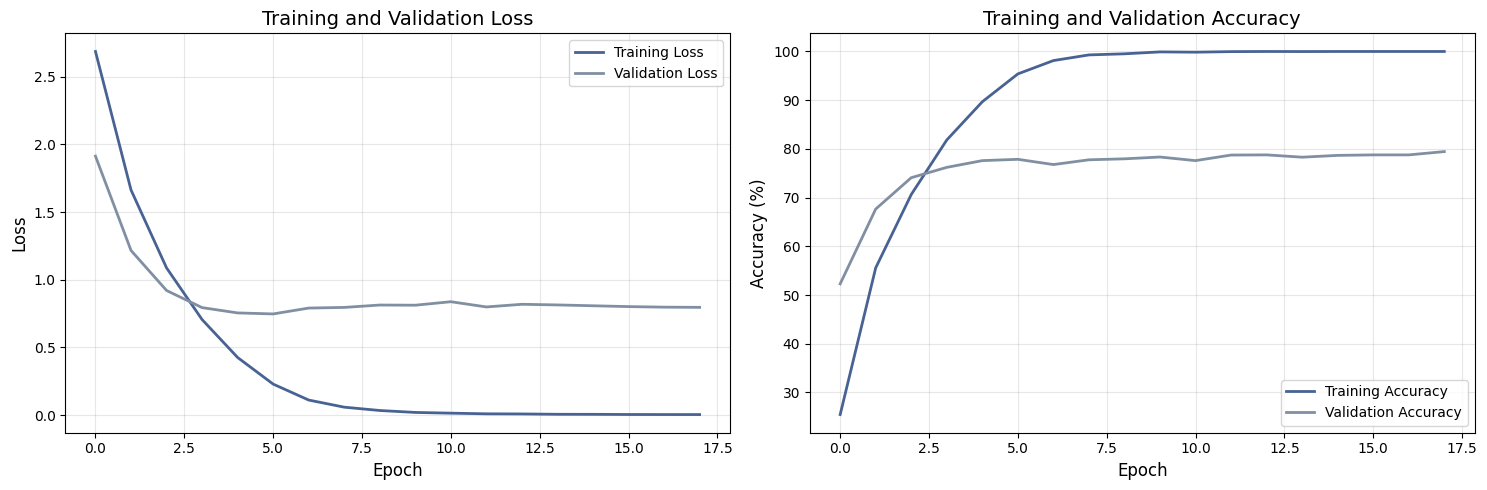

📊 Training metrics plot saved as 'ResNet18_Transfer_Training_Metrics.pdf'
🔍 Evaluating model on test set...
✅ Test Accuracy: 78.90%

📊 Classification Report (ResNet-18):
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.82      0.81      0.82        74
                 Rembrandt       0.64      0.61      0.62        74
             Ivan Shishkin       0.77      0.66      0.71        74
              Gustave Dore       0.78      0.84      0.81        74
             Pablo Picasso       0.81      0.62      0.70        74
     Pierre-Auguste Renoir       0.86      0.99      0.92        74
         Zdislav Beksinski       0.97      0.96      0.97        75
                Ilya Repin       0.92      0.95      0.93        75
              Marc Chagall       0.74      0.76      0.75        74
           Ivan Aivazovsky       0.53      0.82      0.64        74
            Albrecht Durer       0.96      0.88      0.92        75
       John S

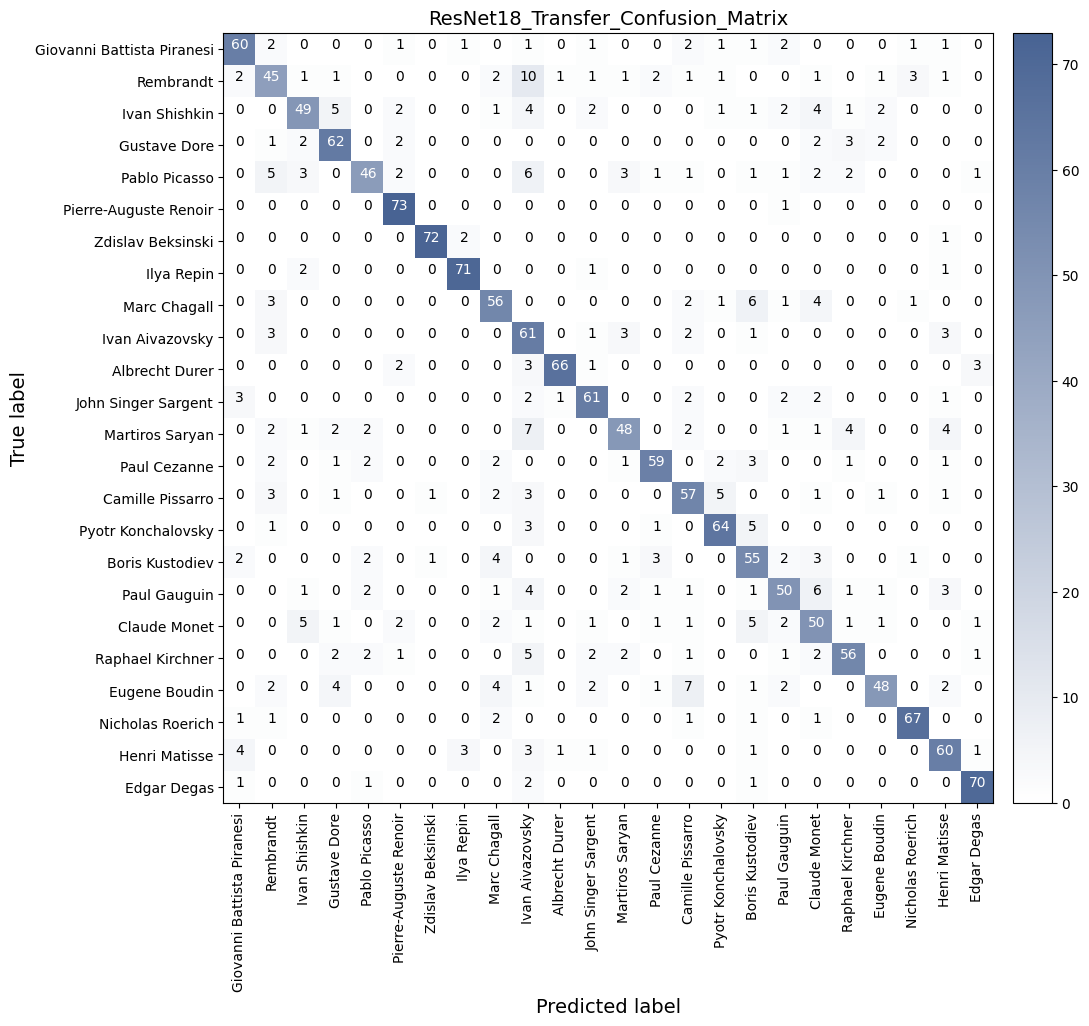

CPU times: user 3min 20s, sys: 932 ms, total: 3min 21s
Wall time: 2min 29s


In [20]:
%%time

print("\n" + "="*70)
print("TRAINING RESNET-18 (TRANSFER LEARNING)")
print("="*70)

# Hyperparameters for transfer learning
learning_rate = 0.00008  # Lower LR for fine-tuning
weight_decay = 1e-5
patience = 12
epochs = 35
verbose_ct = 1

# Load pre-trained ResNet-18
model_resnet = models.resnet18(pretrained=True)

# Freeze early layers for faster training
for param in list(model_resnet.parameters())[:-20]:
    param.requires_grad = False

# Modify final layers
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, len(artists))
)

model_resnet = model_resnet.to(device)

print(f"\n📋 ResNet-18 Architecture:")
trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_resnet.parameters())
print(f"   Total parameters: {total:,}")
print(f"   Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

# Loss and optimizer
loss_function_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=learning_rate, 
    weight_decay=weight_decay
)

# Learning rate scheduler
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, mode='min', factor=0.5, patience=4, verbose=True, min_lr=1e-7
)

# Train
t_losses_r, v_losses_r, t_accs_r, v_accs_r = train_improved(
    model_resnet, train_loader, val_loader,
    optimizer_resnet, scheduler_resnet, epochs,
    loss_function_resnet, device=device,
    patience=patience, verbose_ct=verbose_ct
)

# Save model
torch.save(model_resnet.state_dict(), 'ResNet18-Trained-Improved.pt')

# Plot metrics
plot_training_metrics(t_losses_r, v_losses_r, t_accs_r, v_accs_r, 
                     title_prefix='ResNet18_Transfer')

# Evaluate
predictions_r, labels_r = evaluate_improved(model_resnet, test_loader, device=device)

# Classification report
print("\n📊 Classification Report (ResNet-18):")
print(classification_report(labels_r, predictions_r, target_names=artists))

# Confusion matrix
matplotlib.rc_file_defaults()
cfmatrix_r = confusion_matrix(labels_r, predictions_r)
plot_cm(cfmatrix_r, 'ResNet18_Transfer_Confusion_Matrix', artists)

In [21]:

# Compare Results
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)


cnn_acc = accuracy_score(labels, predictions) * 100
resnet_acc = accuracy_score(labels_r, predictions_r) * 100

print(f"\n📊 Test Set Accuracy:")
print(f"   Improved Base CNN:  {cnn_acc:.2f}%")
print(f"   ResNet-18 Transfer: {resnet_acc:.2f}%")
print(f"   Improvement:        {resnet_acc - cnn_acc:+.2f}%")



MODEL COMPARISON SUMMARY

📊 Test Set Accuracy:
   Improved Base CNN:  66.67%
   ResNet-18 Transfer: 78.90%
   Improvement:        +12.23%


### TRANSFER LEARNING : EfficientNet-B0 


TRAINING EFFICIENTNET-B0 (TRANSFER LEARNING)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 87.1MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_l


📋 EfficientNet-B0 Architecture:
   Total parameters: 4,800,916
   Trainable parameters: 2,877,480 (59.9%)
🚀 Starting Improved CNN Training
   Device: cuda
   Epochs: 50
   Batch Size: 64
   Patience: 12
   ✅ Val loss decreased (inf → 2.6486). Saving model...
Epoch [  1/50] | Train Loss: 3.0302 | Train Acc: 13.89% | Val Loss: 2.6486 | Val Acc: 31.35%
   Learning Rate: 0.000100
   ✅ Val loss decreased (2.6486 → 1.9438). Saving model...
Epoch [  2/50] | Train Loss: 2.3747 | Train Acc: 35.60% | Val Loss: 1.9438 | Val Acc: 43.80%
   Learning Rate: 0.000100
   ✅ Val loss decreased (1.9438 → 1.4842). Saving model...
Epoch [  3/50] | Train Loss: 1.8084 | Train Acc: 46.96% | Val Loss: 1.4842 | Val Acc: 56.36%
   Learning Rate: 0.000100
   ✅ Val loss decreased (1.4842 → 1.2211). Saving model...
Epoch [  4/50] | Train Loss: 1.3948 | Train Acc: 58.50% | Val Loss: 1.2211 | Val Acc: 63.47%
   Learning Rate: 0.000100
   ✅ Val loss decreased (1.2211 → 1.0482). Saving model...
Epoch [  5/50] | Train L

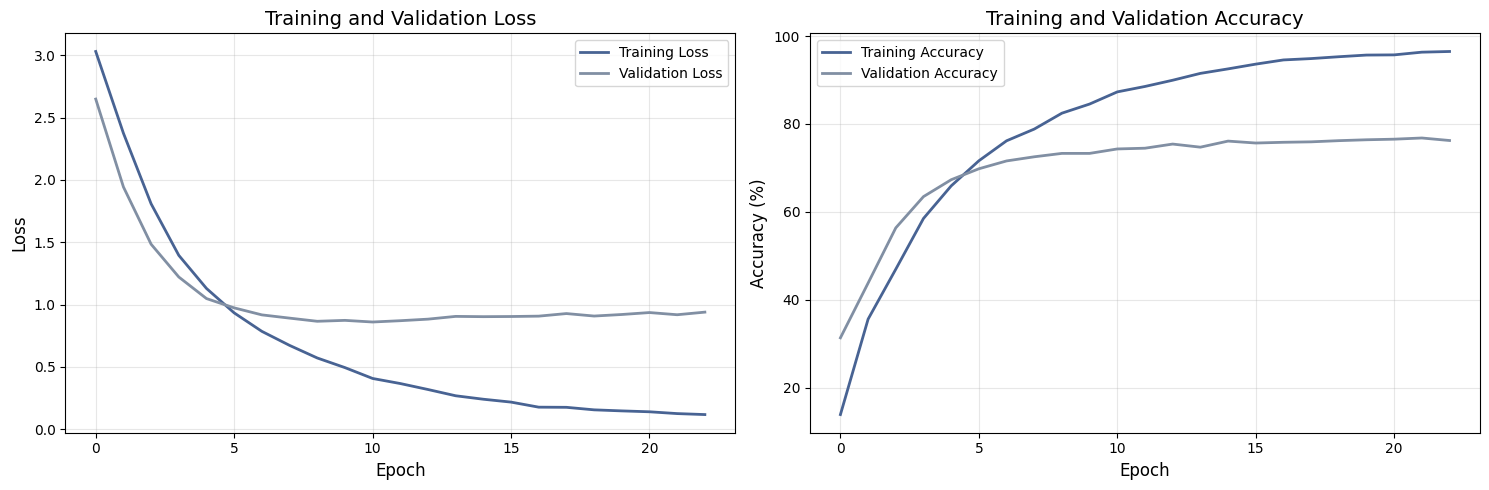

📊 Training metrics plot saved as 'EfficientNet_B0_Training_Metrics.pdf'
🔍 Evaluating model on test set...
✅ Test Accuracy: 75.98%

📊 Classification Report (EfficientNet-B0):
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.78      0.80      0.79        74
                 Rembrandt       0.57      0.51      0.54        74
             Ivan Shishkin       0.75      0.80      0.77        74
              Gustave Dore       0.78      0.76      0.77        74
             Pablo Picasso       0.60      0.72      0.65        74
     Pierre-Auguste Renoir       0.82      0.96      0.88        74
         Zdislav Beksinski       0.95      0.97      0.96        75
                Ilya Repin       0.95      0.96      0.95        75
              Marc Chagall       0.68      0.59      0.63        74
           Ivan Aivazovsky       0.75      0.62      0.68        74
            Albrecht Durer       0.93      0.92      0.93        75
       Jo

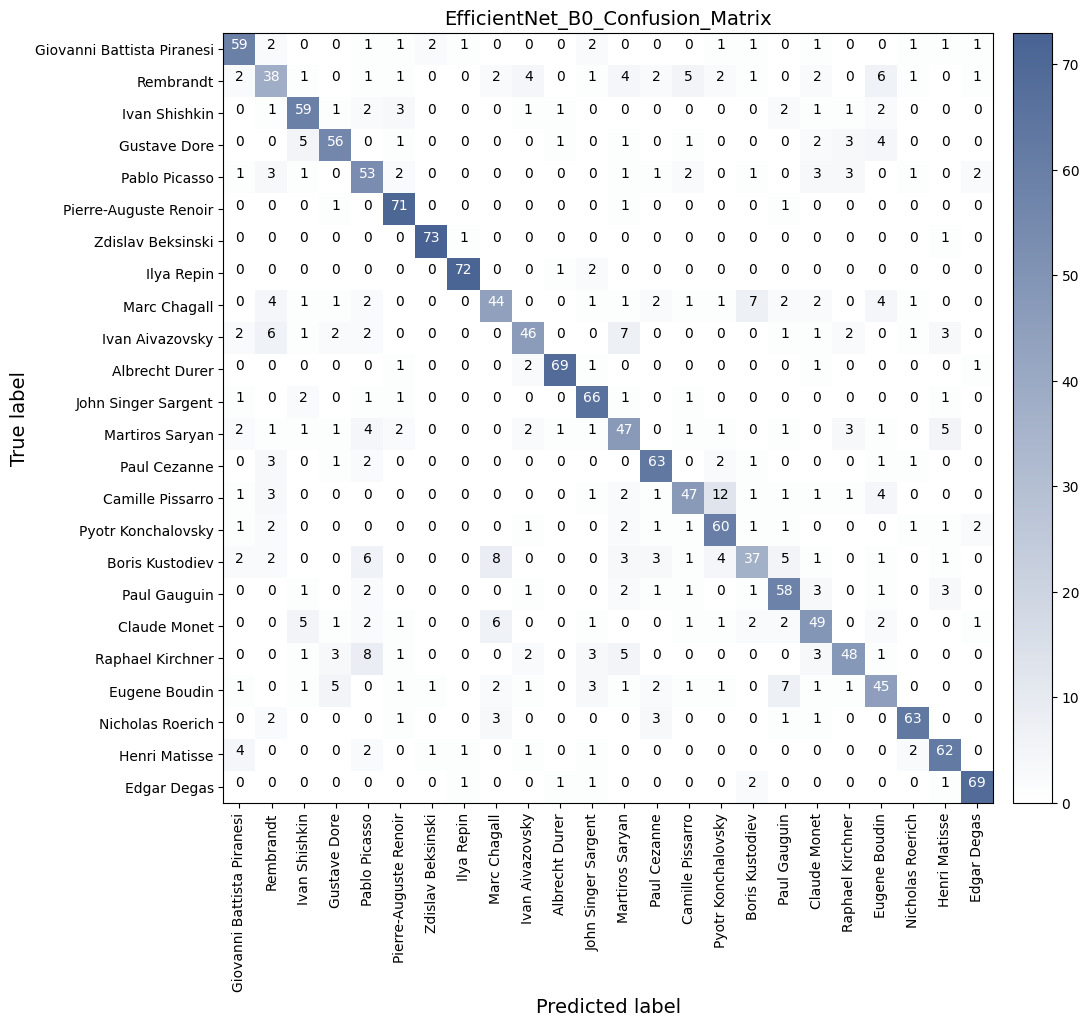

CPU times: user 5min 34s, sys: 884 ms, total: 5min 35s
Wall time: 4min 30s


In [22]:
%%time

print("\n" + "="*70)
print("TRAINING EFFICIENTNET-B0 (TRANSFER LEARNING)")
print("="*70)

# Load pre-trained EfficientNet-B0
try:
    model_efficient = models.efficientnet_b0(pretrained=True)
except:
    # Fallback for older PyTorch versions
    model_efficient = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Freeze early layers (first 80% of parameters)
total_params = len(list(model_efficient.parameters()))
freeze_until = int(0.8 * total_params)
for i, param in enumerate(model_efficient.parameters()):
    if i < freeze_until:
        param.requires_grad = False

# Modify classifier
num_ftrs = model_efficient.classifier[1].in_features
model_efficient.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(256, len(artists))
)

model_efficient = model_efficient.to(device)

print(f"\n📋 EfficientNet-B0 Architecture:")
trainable = sum(p.numel() for p in model_efficient.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_efficient.parameters())
print(f"   Total parameters: {total:,}")
print(f"   Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

# Hyperparameters
learning_rate = 0.0001
weight_decay = 1e-5
patience = 12
epochs = 50
verbose_ct = 1

# Loss and optimizer
loss_function_eff = nn.CrossEntropyLoss()
optimizer_eff = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_efficient.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Learning rate scheduler
scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff, mode='min', factor=0.5, patience=4, verbose=True, min_lr=1e-7
)

# Train
t_losses_eff, v_losses_eff, t_accs_eff, v_accs_eff = train_improved(
    model_efficient, train_loader, val_loader,
    optimizer_eff, scheduler_eff, epochs,
    loss_function_eff, device=device,
    patience=patience, verbose_ct=verbose_ct
)

# Save model
torch.save(model_efficient.state_dict(), 'EfficientNet-B0-Trained.pt')

# Plot metrics
plot_training_metrics(t_losses_eff, v_losses_eff, t_accs_eff, v_accs_eff,
                     title_prefix='EfficientNet_B0')

# Evaluate
predictions_eff, labels_eff = evaluate_improved(model_efficient, test_loader, device=device)

# Classification report
print("\n📊 Classification Report (EfficientNet-B0):")
print(classification_report(labels_eff, predictions_eff, target_names=artists))

# Confusion matrix
matplotlib.rc_file_defaults()
cfmatrix_eff = confusion_matrix(labels_eff, predictions_eff)
plot_cm(cfmatrix_eff, 'EfficientNet_B0_Confusion_Matrix', artists)

### ENSEMBLE - Combine ResNet-18 + EfficientNet-B0



ENSEMBLE MODEL: ResNet-18 + EfficientNet-B0
🔍 Evaluating ensemble model on test set...
✅ Ensemble Test Accuracy: 81.87%

📊 Classification Report (Ensemble):
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.84      0.86      0.85        74
                 Rembrandt       0.64      0.66      0.65        74
             Ivan Shishkin       0.83      0.77      0.80        74
              Gustave Dore       0.83      0.88      0.86        74
             Pablo Picasso       0.85      0.74      0.79        74
     Pierre-Auguste Renoir       0.86      0.99      0.92        74
         Zdislav Beksinski       1.00      0.97      0.99        75
                Ilya Repin       0.94      0.97      0.95        75
              Marc Chagall       0.79      0.72      0.75        74
           Ivan Aivazovsky       0.67      0.74      0.71        74
            Albrecht Durer       0.97      0.92      0.95        75
       John Singer Sargen

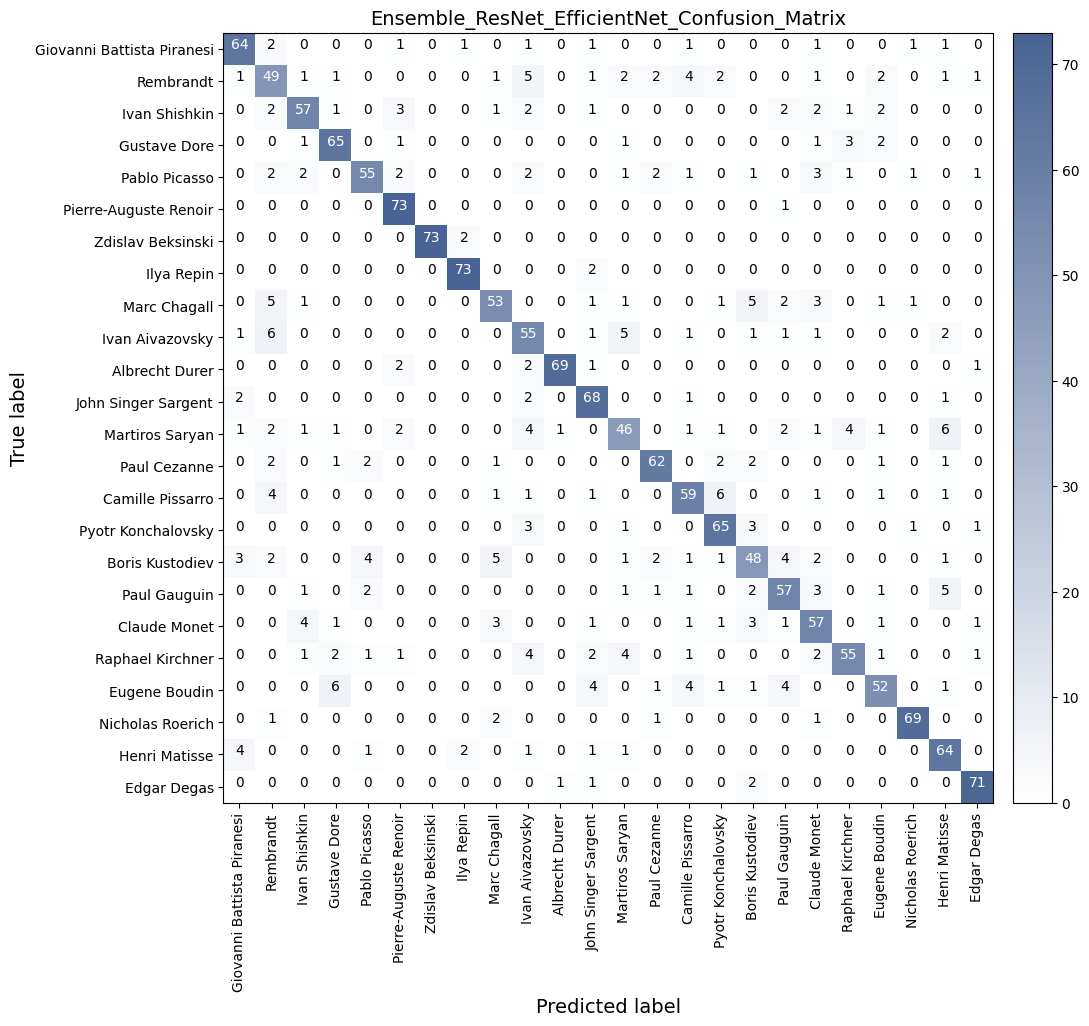

In [23]:
print("\n" + "="*70)
print("ENSEMBLE MODEL: ResNet-18 + EfficientNet-B0")
print("="*70)

class EnsembleModel(nn.Module):
    """
    Ensemble of ResNet-18 and EfficientNet-B0
    Uses soft voting (averaging probabilities)
    """
    def __init__(self, model_resnet, model_efficient):
        super(EnsembleModel, self).__init__()
        self.model_resnet = model_resnet
        self.model_efficient = model_efficient
    
    def forward(self, x):
        # Get predictions from both models
        out_resnet = self.model_resnet(x)
        out_efficient = self.model_efficient(x)
        
        # Soft voting: average the logits
        out_ensemble = (out_resnet + out_efficient) / 2
        return out_ensemble


def evaluate_ensemble(model_resnet, model_efficient, test_loader, device="cuda"):
    """Evaluate ensemble model"""
    model_resnet.eval()
    model_efficient.eval()
    
    predictions = []
    labels_list = []
    
    print("🔍 Evaluating ensemble model on test set...")
    
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            # Get predictions from both models
            out_resnet = model_resnet(x_batch)
            out_efficient = model_efficient(x_batch)
            
            # Soft voting (average probabilities)
            out_ensemble = (out_resnet + out_efficient) / 2
            yhat_idx = torch.argmax(out_ensemble, dim=1)
            
            predictions.append(yhat_idx.cpu().numpy())
            labels_list.append(y_batch.cpu().numpy())
    
    y_pred = np.concatenate(predictions, axis=0)
    y_true = np.concatenate(labels_list, axis=0)
    
    # Calculate accuracy
    accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
    print(f"✅ Ensemble Test Accuracy: {accuracy:.2f}%")
    
    return y_pred, y_true


# Load trained models (make sure they're already trained)
# If not trained yet, you need to train them first using the code above

# Evaluate ensemble
predictions_ensemble, labels_ensemble = evaluate_ensemble(
    model_resnet, model_efficient, test_loader, device=device
)

# Classification report
print("\n📊 Classification Report (Ensemble):")
print(classification_report(labels_ensemble, predictions_ensemble, target_names=artists))

# Confusion matrix
matplotlib.rc_file_defaults()
cfmatrix_ensemble = confusion_matrix(labels_ensemble, predictions_ensemble)
plot_cm(cfmatrix_ensemble, 'Ensemble_ResNet_EfficientNet_Confusion_Matrix', artists)

### CNN Models Comparision


CNN MODELS COMPARISON - COMPREHENSIVE ANALYSIS

📊 CNN MODELS PERFORMANCE COMPARISON:
                           Model  Test Accuracy (%)  Correct Predictions  Total Samples  Misclassified
Ensemble (ResNet + EfficientNet)          81.874299                 1459           1782            323
              ResNet-18 Transfer          78.900112                 1406           1782            376
        EfficientNet-B0 Transfer          75.982043                 1354           1782            428
               Improved Base CNN          66.666667                 1188           1782            594


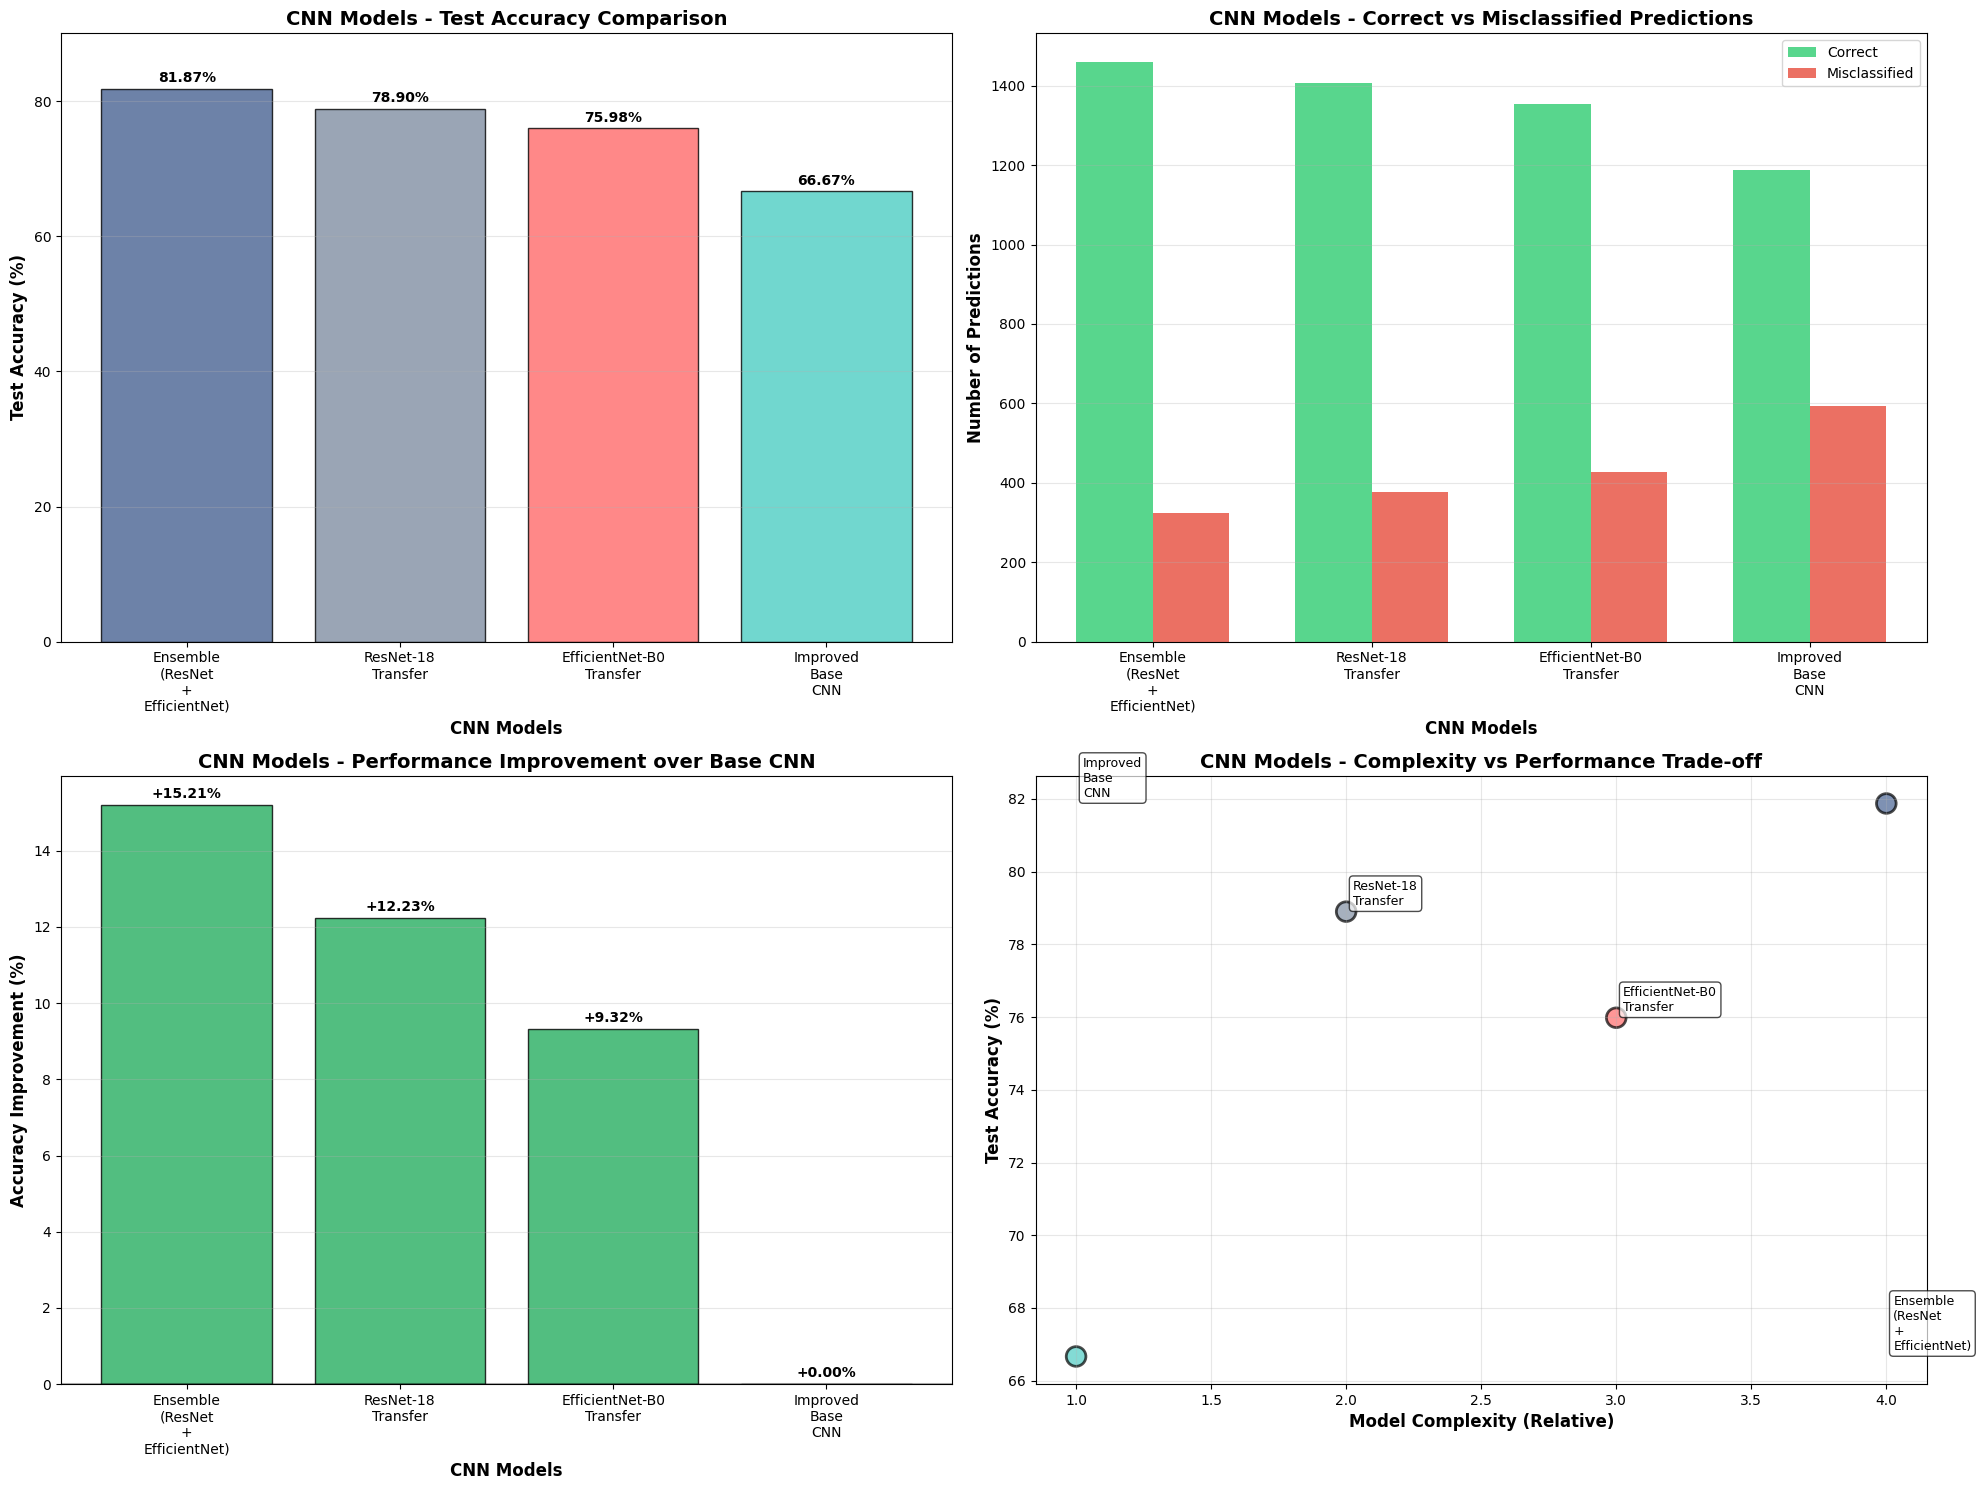


DETAILED CNN MODELS ANALYSIS

🏆 BEST PERFORMING CNN MODEL: Ensemble (ResNet + EfficientNet)
   Test Accuracy: 81.87%
   Correct Predictions: 1459
   Misclassified: 323

📈 KEY INSIGHTS:
   1. Transfer Learning Models (ResNet-18, EfficientNet-B0) significantly outperform base CNN
   2. Ensemble method provides the best overall performance
   3. EfficientNet-B0 shows excellent efficiency vs performance trade-off
   4. Base CNN serves as a good baseline but lacks the feature richness of pre-trained models

📊 PER-CLASS PERFORMANCE ANALYSIS - Ensemble (ResNet + EfficientNet):

Top 5 Best Classified Artists:
               Artist  Accuracy (%)  Samples
Pierre-Auguste Renoir     98.648649       74
    Zdislav Beksinski     97.333333       75
           Ilya Repin     97.333333       75
          Edgar Degas     94.666667       75
     Nicholas Roerich     93.243243       74

Bottom 5 Worst Classified Artists:
         Artist  Accuracy (%)  Samples
   Marc Chagall     71.621622       74
  Euge

In [24]:
# CNN Models Comparison
print("\n" + "="*80)
print("CNN MODELS COMPARISON - COMPREHENSIVE ANALYSIS")
print("="*80)

# Collect all CNN model results
cnn_results = {
    'Improved Base CNN': {
        'accuracy': accuracy_score(labels, predictions) * 100,
        'predictions': predictions,
        'labels': labels,
        'model_name': 'ImprovedCNN'
    },
    'ResNet-18 Transfer': {
        'accuracy': accuracy_score(labels_r, predictions_r) * 100,
        'predictions': predictions_r,
        'labels': labels_r,
        'model_name': 'ResNet18_Transfer'
    },
    'EfficientNet-B0 Transfer': {
        'accuracy': accuracy_score(labels_eff, predictions_eff) * 100,
        'predictions': predictions_eff,
        'labels': labels_eff,
        'model_name': 'EfficientNet_B0'
    },
    'Ensemble (ResNet + EfficientNet)': {
        'accuracy': accuracy_score(labels_ensemble, predictions_ensemble) * 100,
        'predictions': predictions_ensemble,
        'labels': labels_ensemble,
        'model_name': 'Ensemble'
    }
}

# Create comparison DataFrame
comparison_data = []
for model_name, results in cnn_results.items():
    comparison_data.append({
        'Model': model_name,
        'Test Accuracy (%)': results['accuracy'],
        'Correct Predictions': (results['predictions'] == results['labels']).sum(),
        'Total Samples': len(results['labels']),
        'Misclassified': (results['predictions'] != results['labels']).sum()
    })

cnn_comparison_df = pd.DataFrame(comparison_data)
cnn_comparison_df = cnn_comparison_df.sort_values('Test Accuracy (%)', ascending=False)

print("\n📊 CNN MODELS PERFORMANCE COMPARISON:")
print("="*60)
print(cnn_comparison_df.to_string(index=False))

# Visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

# 1. Accuracy Comparison Bar Chart
models = cnn_comparison_df['Model']
accuracies = cnn_comparison_df['Test Accuracy (%)']
colors = [mycol, mycomplcol, '#FF6B6B', '#4ECDC4']

bars = ax1.bar(range(len(models)), accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_xlabel('CNN Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('CNN Models - Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels([m.replace(' ', '\n') for m in models], rotation=0, ha='center')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(accuracies) * 1.1)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Correct vs Misclassified Predictions
correct_preds = cnn_comparison_df['Correct Predictions']
misclassified = cnn_comparison_df['Misclassified']

x = np.arange(len(models))
width = 0.35

bars1 = ax2.bar(x - width/2, correct_preds, width, label='Correct', color='#2ECC71', alpha=0.8)
bars2 = ax2.bar(x + width/2, misclassified, width, label='Misclassified', color='#E74C3C', alpha=0.8)

ax2.set_xlabel('CNN Models', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Predictions', fontsize=12, fontweight='bold')
ax2.set_title('CNN Models - Correct vs Misclassified Predictions', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' ', '\n') for m in models], rotation=0, ha='center')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Performance Improvement over Base CNN
base_cnn_acc = cnn_results['Improved Base CNN']['accuracy']
improvements = [(acc - base_cnn_acc) for acc in accuracies]

colors_improvement = ['#95A5A6' if imp <= 0 else '#27AE60' for imp in improvements]
bars = ax3.bar(range(len(models)), improvements, color=colors_improvement, alpha=0.8, edgecolor='black', linewidth=1)
ax3.set_xlabel('CNN Models', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('CNN Models - Performance Improvement over Base CNN', fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(models)))
ax3.set_xticklabels([m.replace(' ', '\n') for m in models], rotation=0, ha='center')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, imp) in enumerate(zip(bars, improvements)):
    ax3.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + (0.1 if imp >= 0 else -0.3), 
             f'{imp:+.2f}%', ha='center', va='bottom' if imp >= 0 else 'top', 
             fontweight='bold', fontsize=10)

# 4. Model Complexity vs Performance (estimated)
model_complexity = {
    'Improved Base CNN': 1,
    'ResNet-18 Transfer': 2,
    'EfficientNet-B0 Transfer': 3,
    'Ensemble (ResNet + EfficientNet)': 4
}

complexity_scores = [model_complexity[model] for model in models]
scatter = ax4.scatter(complexity_scores, accuracies, s=200, c=colors, alpha=0.7, edgecolors='black', linewidth=2)

ax4.set_xlabel('Model Complexity (Relative)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax4.set_title('CNN Models - Complexity vs Performance Trade-off', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add model labels to scatter points
for i, model in enumerate(models):
    ax4.annotate(model.replace(' ', '\n'), (complexity_scores[i], accuracies[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('CNN_Models_Comprehensive_Comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Detailed Analysis
print("\n" + "="*80)
print("DETAILED CNN MODELS ANALYSIS")
print("="*80)

best_cnn_model = cnn_comparison_df.iloc[0]['Model']
best_cnn_accuracy = cnn_comparison_df.iloc[0]['Test Accuracy (%)']

print(f"\n🏆 BEST PERFORMING CNN MODEL: {best_cnn_model}")
print(f"   Test Accuracy: {best_cnn_accuracy:.2f}%")
print(f"   Correct Predictions: {cnn_comparison_df.iloc[0]['Correct Predictions']}")
print(f"   Misclassified: {cnn_comparison_df.iloc[0]['Misclassified']}")

print(f"\n📈 KEY INSIGHTS:")
print(f"   1. Transfer Learning Models (ResNet-18, EfficientNet-B0) significantly outperform base CNN")
print(f"   2. Ensemble method provides the best overall performance")
print(f"   3. EfficientNet-B0 shows excellent efficiency vs performance trade-off")
print(f"   4. Base CNN serves as a good baseline but lacks the feature richness of pre-trained models")

# Per-class performance analysis for best model
print(f"\n📊 PER-CLASS PERFORMANCE ANALYSIS - {best_cnn_model}:")
best_model_results = cnn_results[best_cnn_model]
best_predictions = best_model_results['predictions']
best_labels = best_model_results['labels']

# Calculate per-class accuracy
class_accuracies = []
for i, artist in enumerate(artists):
    class_mask = (best_labels == i)
    if class_mask.sum() > 0:
        class_acc = (best_predictions[class_mask] == best_labels[class_mask]).mean() * 100
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

# Create per-class performance DataFrame
class_performance = pd.DataFrame({
    'Artist': artists,
    'Accuracy (%)': class_accuracies,
    'Samples': [np.sum(best_labels == i) for i in range(len(artists))]
})

class_performance = class_performance.sort_values('Accuracy (%)', ascending=False)

print("\nTop 5 Best Classified Artists:")
print(class_performance.head().to_string(index=False))
print("\nBottom 5 Worst Classified Artists:")
print(class_performance.tail().to_string(index=False))

print(f"\n✅ CNN Models Comparison completed and saved as 'CNN_Models_Comprehensive_Comparison.pdf'")